# EDA 10: Supplementary microRNA

## Purpose

MicroRNAs are very small RNA molecules that can reduce how much protein is made from other RNA messages. They act like dimmer switches rather than DNA mutations. One microRNA can affect several genes, and one gene can be affected by several microRNAs.

This 2018-era table covers 949 models and uses internal `nmiR...` identifiers. Without a verified identifier-to-name and target map, it can describe regulatory patterns but cannot yet explain which queried gene is being regulated.

## Column dictionary

| Column | Plain-language meaning | Use in this project |
| --- | --- | --- |
| `model_id` | DepMap cell-line identifier. | Only automatic model join key. |
| `nmiRxxxxx.x` | Expression measurement for one internal microRNA feature. | Regulatory-pattern context after identifier annotation is added. |

The values are non-negative expression measurements and are strongly right-skewed. A `log1p` view is used for plots, but the source values remain unchanged.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option('display.max_columns',100); pd.set_option('display.max_rows',100)
sns.set_theme(style='whitegrid',context='notebook')
def find_root(start):
    for candidate in (start,*start.parents):
        if (candidate/'data'/'depmap_24Q4'/'architecture'/'model_master.csv').exists(): return candidate
    raise FileNotFoundError('Run inside the az-team25 repository.')
PROJECT_ROOT=find_root(Path.cwd().resolve()); DATA=PROJECT_ROOT/'data'/'depmap_24Q4'
master=pd.read_csv(DATA/'architecture'/'model_master.csv',low_memory=False)

mirna=pd.read_csv(DATA/'supplementary'/'mirna_model.csv',low_memory=False); features=mirna.columns[1:].tolist()
print(f'{len(mirna):,} models x {len(features):,} miRNA features'); display(mirna.iloc[:3,:10])

949 models x 734 miRNA features


,model_id,nmiR00001.1,nmiR00002.1,nmiR00003.1,nmiR00004.1,nmiR00005.1,nmiR00006.1,nmiR00007.1,nmiR00008.1,nmiR00009.1
0,ACH-000001,5870.61,301.12,1591.66,986.77,201.05,1127.24,1762.85,888.45,20.19
1,ACH-000002,24286.14,960.32,286.69,5679.45,183.63,7916.75,13217.69,3442.15,14.05
2,ACH-000004,8018.34,224.86,642.22,289.59,1044.24,596.22,957.36,761.46,39.18


## 1. Identity, coverage, and measurement behaviour

We check unique model mapping, missing values, zeros, and the large range of expression measurements.

,rows,unique_models,duplicate_models,models_not_in_master,master_coverage_pct
0,949,949,0,0,45.083135


,count,mean,std,min,25%,50%,75%,max
mean,734.0,379.456569,1496.879311,1.509294,17.046104,28.759721,96.606515,18254.164131
median,734.0,228.893910,1016.333695,1.050000,13.600000,20.855000,45.340000,13986.260000
sd,734.0,559.275560,1905.699559,2.755739,9.145103,25.982013,200.862138,21904.659896
zero_pct,734.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
missing_pct,734.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


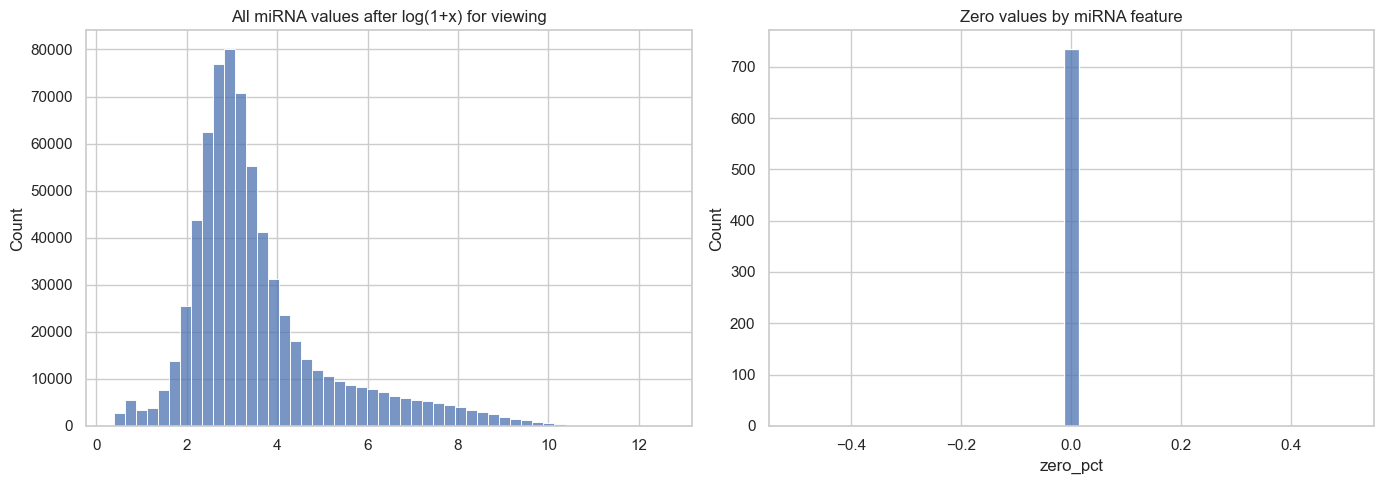

In [2]:
ids=set(mirna['model_id']); audit=pd.DataFrame([{'rows':len(mirna),'unique_models':mirna['model_id'].nunique(),'duplicate_models':int(mirna['model_id'].duplicated().sum()),'models_not_in_master':len(ids-set(master['model_id'])),'master_coverage_pct':100*len(ids)/len(master)}]); display(audit); assert mirna['model_id'].is_unique
values=mirna[features]
feature_summary=pd.DataFrame({'feature':features,'mean':values.mean().values,'median':values.median().values,'sd':values.std().values,'zero_pct':100*values.eq(0).mean().values,'missing_pct':100*values.isna().mean().values})
display(feature_summary[['mean','median','sd','zero_pct','missing_pct']].describe().T)
fig,axes=plt.subplots(1,2,figsize=(14,5)); sns.histplot(np.log1p(values.to_numpy().ravel()),bins=50,ax=axes[0]); axes[0].set_title('All miRNA values after log(1+x) for viewing'); sns.histplot(feature_summary['zero_pct'],bins=35,ax=axes[1]); axes[1].set_title('Zero values by miRNA feature'); plt.tight_layout(); plt.show()

### What this means for the project

A very large miRNA value means that small regulatory RNA was measured at a high level. It does not tell us which protein changed unless the miRNA identifier and its experimentally supported targets are known.

## 2. Variable features and lineage patterns

We use the most variable features to understand broad structure, not to claim gene targets.

,feature,mean,median,sd,zero_pct,missing_pct
598,nmiR00631.1,17158.592740,11065.33,21904.659896,0.0,0.0
207,nmiR00232.1,6416.881012,25.42,19250.340428,0.0,0.0
214,nmiR00236.1,16034.273130,9521.50,18335.865535,0.0,0.0
0,nmiR00001.1,18254.164131,13986.26,15486.892099,0.0,0.0
327,nmiR00344.2,2887.125838,25.12,13902.928948,0.0,0.0
260,nmiR00275.1,10524.491675,7136.21,11210.032242,0.0,0.0
153,nmiR00181.1,12467.586238,9580.91,10458.884460,0.0,0.0
215,nmiR00238.1,6177.784795,3532.54,9823.941717,0.0,0.0
273,nmiR00288.1,5357.841444,3660.94,9053.944703,0.0,0.0
200,nmiR00225.1,7953.092550,5100.98,8611.178171,0.0,0.0


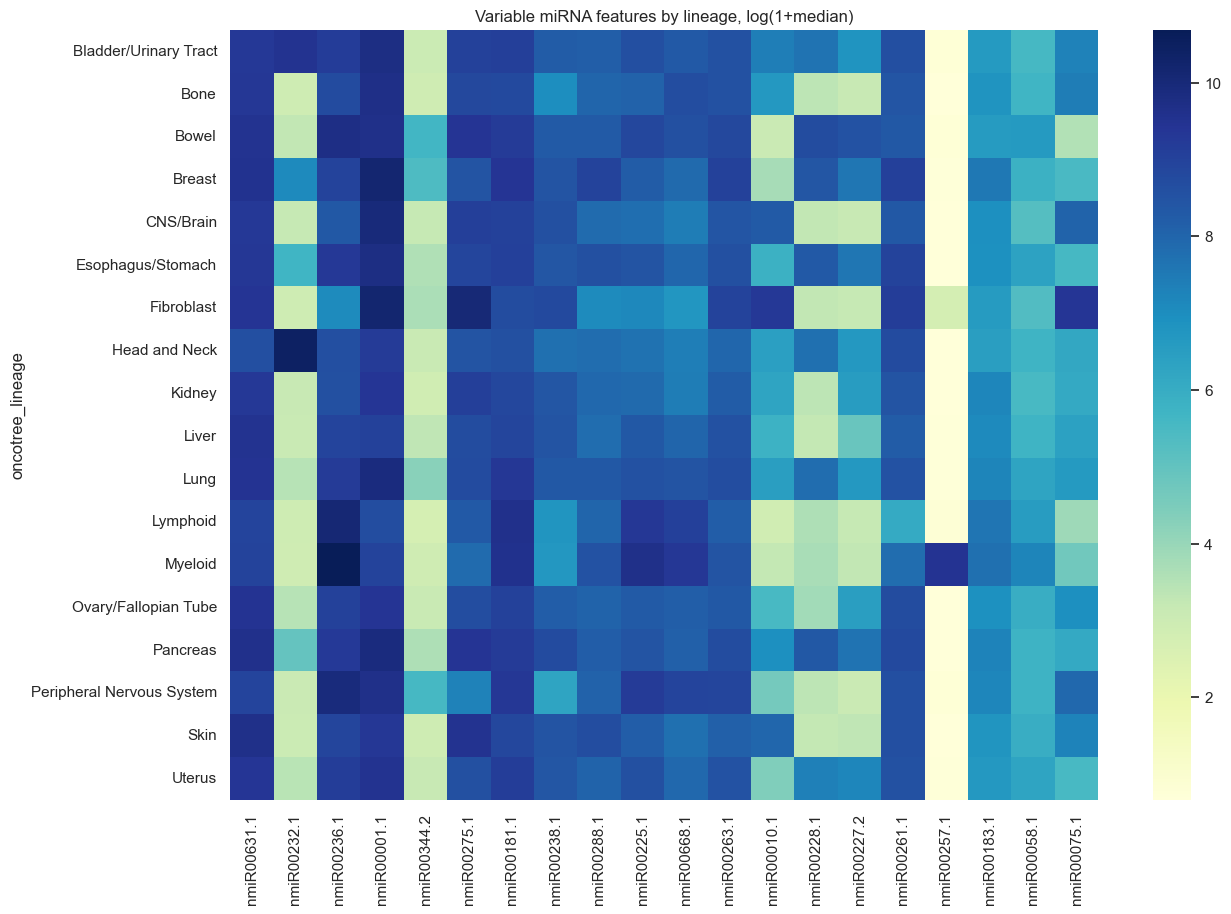

In [3]:
top=feature_summary.nlargest(20,'sd')['feature'].tolist(); display(feature_summary.loc[feature_summary['feature'].isin(top)].sort_values('sd',ascending=False))
context=mirna[['model_id',*top]].merge(master[['model_id','oncotree_lineage']],on='model_id',how='left',validate='one_to_one')
large=context['oncotree_lineage'].value_counts(); large=large[large.ge(15)].index
medians=np.log1p(context.loc[context['oncotree_lineage'].isin(large)].groupby('oncotree_lineage')[top].median())
plt.figure(figsize=(14,10)); sns.heatmap(medians,cmap='YlGnBu'); plt.title('Variable miRNA features by lineage, log(1+median)'); plt.show()

### What this means for the project

If a microRNA pattern is concentrated in one lineage, it may describe that cancer type rather than a specific gene pair. Until IDs and targets are annotated, these features remain exploratory regulatory context.

## Decisions carried into metabolomics EDA

- Keep miRNA outside the core score because it is older and lacks a verified target mapping here.
- Preserve source values; use log transformation only for visualisation or a documented model pipeline.
- Do not label an `nmiR` feature as regulating gene A or B without external target evidence.
- Report lineage and measurement denominators for any future use.